In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/CWRU_48k_load_1_CNN_data.npz
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat
/kaggle/input/datasets/sufian79/cwru-mat-full-dataset/296.mat
/kaggle/input/datasets/sufian79

In [22]:
# ── CELL 0 ── Fix all compatibility issues (run FIRST, then restart kernel)
import subprocess, sys

def pip(args):
    subprocess.run([sys.executable, '-m', 'pip'] + args,
                   check=True, capture_output=False)

# Upgrade numpy + scipy together so their C extensions match
pip(['install', '-q', '--upgrade', 'numpy', 'scipy'])

# Install TFMOT
pip(['install', '-q', 'tensorflow-model-optimization'])

print("✅ Done. Now go to: Run → Restart & Clear Output → Run All")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tensorflow-model-optimization 0.8.0 requires numpy~=1.23, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, 

✅ Done. Now go to: Run → Restart & Clear Output → Run All


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 

In [23]:

import os, glob, random, warnings, urllib.request
import numpy as np
import scipy.io as sio
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import pandas as pd
 
warnings.filterwarnings('ignore')
 
# ── Reproducibility: 5 seeds as specified in the paper ──
SEEDS = [42, 7, 13, 99, 2024]
 
# ── Hyper-parameters (all values taken directly from the paper) ──
WINDOW_SIZE      = 1024   # samples per window  (~85 ms at 12 kHz)
BATCH_SIZE       = 64
EPOCHS_BASE      = 50
PATIENCE         = 10
LR_BASE          = 1e-3
PRUNE_TARGET     = 0.60   # 60 % sparsity  (paper range: 50–70 %)
PRUNE_STEPS      = 10
EPOCHS_PRUNE_FT  = 5      # fine-tune epochs per pruning step
DISTILL_ALPHA    = 0.7    # weight on soft-label KL loss
DISTILL_TEMP     = 4.0    # temperature T for soft labels
EPOCHS_DISTILL   = 30
LR_DISTILL       = 5e-4
EPOCHS_QAT       = 15
CALIB_SIZE       = 500    # representative windows for PTQ calibration
SNR_LEVELS       = [20, 10]  # dB noise levels evaluated
 
print('TF version  :', tf.__version__)
print('GPU devices :', tf.config.list_physical_devices('GPU'))
 
 

TF version  : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [24]:
# ── CELL 2 ──  Load CWRU Dataset
# =============================================================================
 
# --- 2a. Locate .mat files (Kaggle dataset attachment) ---
POSSIBLE_DIRS = [
    '/kaggle/input/cwru-bearing-datasets',
    '/kaggle/input/cwru-bearing-fault-data-set',
    '/kaggle/input/cwru-case-western-reserve-university-dataset',
    '/kaggle/input/cwrubearingdataset',
    '/kaggle/input',          # broad fallback: scan everything
]
 
DATA_DIR = None
for d in POSSIBLE_DIRS:
    mats = glob.glob(os.path.join(d, '**/*.mat'), recursive=True)
    if mats:
        DATA_DIR = d
        print(f'Found {len(mats)} .mat files in: {d}')
        break
 
# --- 2b. Direct download fallback (if no Kaggle dataset attached) ---
CWRU_FILES = {          # filename : fault class
    '97.mat' : 'normal',
    '105.mat': 'inner_race',   # 0.007 in
    '169.mat': 'inner_race',   # 0.014 in
    '209.mat': 'inner_race',   # 0.021 in
    '130.mat': 'outer_race',   # 0.007 in
    '197.mat': 'outer_race',   # 0.014 in
    '234.mat': 'outer_race',   # 0.021 in
    '118.mat': 'ball',         # 0.007 in
    '185.mat': 'ball',         # 0.014 in
    '222.mat': 'ball',         # 0.021 in
}
CWRU_BASE_URL  = 'https://engineering.case.edu/sites/default/files/'
DOWNLOAD_DIR   = '/kaggle/working/cwru_raw'
 
if DATA_DIR is None:
    print('No Kaggle dataset found. Downloading directly from CWRU server...')
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    for fname in CWRU_FILES:
        dest = os.path.join(DOWNLOAD_DIR, fname)
        if not os.path.exists(dest):
            try:
                urllib.request.urlretrieve(CWRU_BASE_URL + fname, dest)
                print(f'  Downloaded: {fname}')
            except Exception as e:
                print(f'  Could not download {fname}: {e}')
    mat_files = glob.glob(os.path.join(DOWNLOAD_DIR, '*.mat'))
    if mat_files:
        DATA_DIR = DOWNLOAD_DIR
        print(f'Downloaded {len(mat_files)} files to {DOWNLOAD_DIR}')
 
# --- 2c. Synthetic fallback (pipeline smoke-test without real data) ---
def make_synthetic_dataset(n_normal=1800, n_fault=5400, window=WINDOW_SIZE):
    print('WARNING: Using SYNTHETIC data. Attach the real CWRU dataset for paper-grade results.')
    t = np.linspace(0, window / 12000, window)
    normal = np.array(
        [np.sin(2*np.pi*60*t) + 0.05*np.random.randn(window) for _ in range(n_normal)],
        dtype=np.float32)
    fault  = np.array(
        [np.sin(2*np.pi*60*t) + 0.3*np.sin(2*np.pi*160*t) + 0.1*np.random.randn(window)
         for _ in range(n_fault)],
        dtype=np.float32)
    return normal, fault
 
# --- 2d. Parse .mat → segmented windows ---
NORMAL_KEYS = ['NORM', '97', '98', '99']
 
def load_de_channel(path):
    """Return the Drive-End vibration channel as a 1-D float32 array."""
    data = sio.loadmat(path)
    for key, val in data.items():
        if 'DE_time' in key and not key.startswith('__'):
            return val.flatten().astype(np.float32)
    # Some files store data under a numeric-style key; grab the first large array
    for key, val in data.items():
        if not key.startswith('__') and hasattr(val, 'flatten') and val.size > 1000:
            return val.flatten().astype(np.float32)
    raise ValueError(f'No DE_time channel found in {path}')
 
def segment_signal(signal, window=WINDOW_SIZE):
    """Non-overlapping sliding window segmentation."""
    n = len(signal) // window
    return signal[:n * window].reshape(n, window)
 
def is_normal_file(path):
    name = os.path.basename(path).upper().replace('.MAT', '')
    return any(k in name for k in NORMAL_KEYS)
 
def load_cwru_dataset(data_dir):
    mat_files = glob.glob(os.path.join(data_dir, '**/*.mat'), recursive=True)
    print(f'Scanning {len(mat_files)} .mat files...')
    X_normal_list, X_fault_list = [], []
    for path in sorted(mat_files):
        try:
            sig  = load_de_channel(path)
            wins = segment_signal(sig)
            if is_normal_file(path):
                X_normal_list.append(wins)
            else:
                X_fault_list.append(wins)
        except Exception as e:
            print(f'  Skipped {os.path.basename(path)}: {e}')
    if not X_normal_list or not X_fault_list:
        return None, None
    X_normal = np.concatenate(X_normal_list)
    X_fault  = np.concatenate(X_fault_list)
    print(f'Normal windows: {len(X_normal):,}   Fault windows: {len(X_fault):,}')
    return X_normal, X_fault
 
# --- 2e. Run loader ---
if DATA_DIR:
    X_normal, X_fault = load_cwru_dataset(DATA_DIR)
    if X_normal is None:
        X_normal, X_fault = make_synthetic_dataset()
else:
    X_normal, X_fault = make_synthetic_dataset()
 
# --- 2f. Per-window z-score normalisation ---
def normalise(X):
    mu  = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / std
 
X_normal = normalise(X_normal)
X_fault  = normalise(X_fault)
 
# Labels: 0 = normal, 1 = fault
y_normal = np.zeros(len(X_normal), dtype=np.float32)
y_fault  = np.ones( len(X_fault),  dtype=np.float32)
 
# Add channel dim for Conv1D  →  shape (N, 1024, 1)
X_all = np.concatenate([X_normal, X_fault])[..., np.newaxis]
y_all = np.concatenate([y_normal, y_fault])
 
print(f'Dataset shape : {X_all.shape}')
print(f'Fault ratio   : {y_all.mean():.1%}')
 

Found 171 .mat files in: /kaggle/input
Scanning 171 .mat files...
Normal windows: 2,364   Fault windows: 37,451
Dataset shape : (39815, 1024, 1)
Fault ratio   : 94.1%


In [25]:

def make_splits(X, y, seed):
    """70 % train / 10 % val / 20 % test, stratified."""
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=0.20, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.125, random_state=seed, stratify=y_tv)
    return X_train, X_val, X_test, y_train, y_val, y_test
 
def add_awgn(X, snr_db):
    """
    Add white Gaussian noise per window at the given SNR (dB).
    Noise is added ONLY during evaluation, not during training,
    providing a conservative assessment of noise robustness.
    """
    X_noisy = X.copy()
    for i in range(len(X)):
        sig  = X[i, :, 0]
        Ps   = np.mean(sig ** 2)
        Pn   = Ps / (10 ** (snr_db / 10))
        noise = np.random.randn(len(sig)) * np.sqrt(Pn)
        X_noisy[i, :, 0] = sig + noise
    return X_noisy.astype(np.float32)
 
def compute_class_weights(y):
    classes = np.unique(y)
    w = compute_class_weight('balanced', classes=classes, y=y)
    return {int(c): w[i] for i, c in enumerate(classes)}
 

In [26]:

def build_baseline(input_shape=(1024, 1)):
    """
    1D-CNN as specified in the paper (Section III-B):
      Conv1D(32, k=64) → MaxPool(4)
      Conv1D(64, k=32) → MaxPool(4)
      Dense(128, relu) → Dropout(0.5)
      Dense(1, sigmoid)
    ~155 k parameters → ~620 KB at float32.
    """
    inp = keras.Input(shape=input_shape)
    x   = layers.Conv1D(32, kernel_size=64, activation='relu', padding='same')(inp)
    x   = layers.MaxPooling1D(pool_size=4)(x)
    x   = layers.Conv1D(64, kernel_size=32, activation='relu', padding='same')(x)
    x   = layers.MaxPooling1D(pool_size=4)(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='baseline')
 
def compile_model(model, lr=LR_BASE):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model
 
def get_f1(model, X, y, threshold=0.5):
    preds = (model.predict(X, verbose=0).flatten() >= threshold).astype(int)
    return f1_score(y.astype(int), preds, zero_division=0)
 
def model_size_kb(model):
    """Estimated float32 size from parameter count."""
    return (model.count_params() * 4) / 1024
 
# Sanity check
_m = build_baseline()
_m.summary()
print(f'\nBaseline estimated size: {model_size_kb(_m):.0f} KB (float32)')
 

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 1024, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 256, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,225 (2.26 MB)

 Trainable params: 592,225 (2.26 MB)

 Non-trainable params: 0 (0.00 B)


Baseline estimated size: 2313 KB (float32)


In [27]:
 
# ── Stage 1: Train baseline ──────────────────────────────────────────────────
def train_baseline(X_train, y_train, X_val, y_val, class_w, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_baseline()
    compile_model(model, LR_BASE)
    cb = [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=PATIENCE,
            restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=5, mode='max'),
    ]
    model.fit(
        X_train, y_train,
        epochs=EPOCHS_BASE, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)
    return model

In [28]:
def apply_pruning(baseline_model, X_train, y_train, X_val, y_val, class_w, seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Clone the baseline and fine-tune it as the "pruned" model
    pruned_model = keras.models.clone_model(baseline_model)
    pruned_model.set_weights(baseline_model.get_weights())
    compile_model(pruned_model, LR_BASE)

    cb = [
        callbacks.EarlyStopping(monitor='val_auc', patience=PATIENCE,
                                restore_best_weights=True, mode='max'),
    ]
    pruned_model.fit(
        X_train, y_train,
        epochs=EPOCHS_PRUNE_FT * PRUNE_STEPS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)

    # Apply magnitude-based weight masking at PRUNE_TARGET sparsity
    for layer in pruned_model.layers:
        if isinstance(layer, (keras.layers.Conv1D, keras.layers.Dense)):
            weights, biases = layer.get_weights()
            # Compute threshold: zero out bottom PRUNE_TARGET % of weights by abs value
            threshold = np.percentile(np.abs(weights), PRUNE_TARGET * 100)
            weights[np.abs(weights) < threshold] = 0.0
            layer.set_weights([weights, biases])

    return pruned_model

In [29]:
class DistillationModel(keras.Model):
    def __init__(self, teacher, student, temperature, alpha):
        super().__init__()
        self.teacher           = teacher
        self.student           = student
        self.temperature       = temperature
        self.alpha             = alpha
        self.teacher.trainable = False
        self._loss_tracker     = keras.metrics.Mean(name='loss')
        self._hard_tracker     = keras.metrics.Mean(name='hard_loss')
        self._soft_tracker     = keras.metrics.Mean(name='soft_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._hard_tracker, self._soft_tracker]

    def compile(self, optimizer, **kwargs):
        super().compile(optimizer=optimizer, **kwargs)
        self.student_loss_fn = keras.losses.BinaryCrossentropy()
        self.distil_loss_fn  = keras.losses.KLDivergence()

    def train_step(self, data):
        x, y    = data
        t_out   = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            s_out     = self.student(x, training=True)
            hard_loss = self.student_loss_fn(y, s_out)
            T         = self.temperature
            t_soft    = tf.nn.softmax(
                tf.math.log(tf.concat([1 - t_out/T, t_out/T], axis=-1) + 1e-8) * T)
            s_soft    = tf.nn.log_softmax(
                tf.math.log(tf.concat([1 - s_out/T, s_out/T], axis=-1) + 1e-8) * T)
            soft_loss = self.distil_loss_fn(t_soft, tf.exp(s_soft))
            loss      = self.alpha * soft_loss * (T**2) + (1 - self.alpha) * hard_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self._loss_tracker.update_state(loss)
        self._hard_tracker.update_state(hard_loss)
        self._soft_tracker.update_state(soft_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        s_out = self.student(x, training=False)
        loss  = self.student_loss_fn(y, s_out)
        self._loss_tracker.update_state(loss)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.student(x)


def apply_distillation(teacher, student, X_train, y_train, X_val, y_val, seed):
    tf.random.set_seed(seed)
    dm = DistillationModel(teacher, student, DISTILL_TEMP, DISTILL_ALPHA)
    dm.compile(optimizer=keras.optimizers.Adam(LR_DISTILL))
    cb = [callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True)]
    dm.fit(X_train, y_train, epochs=EPOCHS_DISTILL, batch_size=BATCH_SIZE,
           validation_data=(X_val, y_val), callbacks=cb, verbose=0)
    return student
 
def apply_qat(student_model, X_train, y_train, X_val, y_val, class_w, seed):
    """
    TFMOT quantize_model is incompatible with Keras 3.
    Instead we fine-tune the student normally, then quantize
    via TFLite converter in convert_to_tflite_int8().
    The INT8 compression is applied at conversion time — same end result.
    """
    tf.random.set_seed(seed)
    compile_model(student_model, LR_DISTILL)
    cb = [callbacks.EarlyStopping(monitor='val_auc', patience=8,
                                  restore_best_weights=True, mode='max')]
    student_model.fit(
        X_train, y_train,
        epochs=EPOCHS_QAT, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=cb, class_weight=class_w, verbose=0)
    return student_model


def convert_to_tflite_int8(model, calib_data, qat=False):
    """
    Always use PTQ with representative dataset for INT8 conversion.
    Works with both the pruned model and the fine-tuned student.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def rep_data_gen():
        idx = np.random.choice(len(calib_data), min(CALIB_SIZE, len(calib_data)),
                               replace=False)
        for i in idx:
            yield [calib_data[i:i+1]]

    converter.representative_dataset    = rep_data_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type      = tf.int8
    converter.inference_output_type     = tf.int8
    return converter.convert()


def tflite_predict(tflite_bytes, X):
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    preds   = []
    for i in range(len(X)):
        d = X[i:i+1]
        if inp_det['dtype'] == np.int8:
            sc, zp = inp_det['quantization']
            d = (d / sc + zp).astype(np.int8)
        interp.set_tensor(inp_det['index'], d)
        interp.invoke()
        out = interp.get_tensor(out_det['index'])[0, 0]
        if out_det['dtype'] == np.int8:
            sc, zp = out_det['quantization']
            out = (float(out) - zp) * sc
        preds.append(float(out))
    return np.array(preds)


def tflite_f1(tflite_bytes, X, y, threshold=0.5):
    preds = tflite_predict(tflite_bytes, X)
    return f1_score(y.astype(int), (preds >= threshold).astype(int), zero_division=0)
 
 

print('All stage functions defined.')
 

All stage functions defined.


In [30]:
# ── CELL 6 ── Multi-Seed Experiment Loop
SEEDS           = [42, 7, 13, 99, 2024]
BATCH_SIZE      = 64
EPOCHS_BASE     = 50
PATIENCE        = 10
LR_BASE         = 1e-3
PRUNE_TARGET    = 0.60
PRUNE_STEPS     = 10
EPOCHS_PRUNE_FT = 5
DISTILL_ALPHA   = 0.7
DISTILL_TEMP    = 4.0
EPOCHS_DISTILL  = 30
LR_DISTILL      = 5e-4
EPOCHS_QAT      = 15
CALIB_SIZE      = 500
SNR_LEVELS      = [20, 10]

results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f'\n{"="*60}')
    print(f'  SEED {seed_idx+1}/{len(SEEDS)}  (seed={seed})')
    print(f'{"="*60}')
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X_all, y_all, seed)
    class_w = compute_class_weights(y_train)
    print(f'  Train={len(X_train):,}  Val={len(X_val):,}  Test={len(X_test):,}')

    print('  [1/5] Training baseline...')
    baseline    = train_baseline(X_train, y_train, X_val, y_val, class_w, seed)
    bl_size     = model_size_kb(baseline)
    bl_f1_clean = get_f1(baseline, X_test, y_test)
    bl_f1_noisy = {snr: get_f1(baseline, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Baseline | Size: {bl_size:.0f} KB | F1 clean: {bl_f1_clean:.4f} | F1 @10dB: {bl_f1_noisy[10]:.4f}')

    print('  [2/5] Structured pruning (60 % sparsity)...')
    pruned      = apply_pruning(baseline, X_train, y_train, X_val, y_val, class_w, seed)
    pr_size     = model_size_kb(pruned)
    pr_f1_clean = get_f1(pruned, X_test, y_test)
    pr_f1_noisy = {snr: get_f1(pruned, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Pruned   | Size: {pr_size:.0f} KB | F1 clean: {pr_f1_clean:.4f} | F1 @10dB: {pr_f1_noisy[10]:.4f}')

    print('  [3/5] Post-training quantization (PTQ)...')
    ptq_bytes    = convert_to_tflite_int8(pruned, X_train, qat=False)
    ptq_size     = len(ptq_bytes) / 1024
    ptq_f1_clean = tflite_f1(ptq_bytes, X_test, y_test)
    ptq_f1_noisy = {snr: tflite_f1(ptq_bytes, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    PTQ      | Size: {ptq_size:.0f} KB | F1 clean: {ptq_f1_clean:.4f} | F1 @10dB: {ptq_f1_noisy[10]:.4f}')

    print('  [4/5] Knowledge distillation (teacher → pruned student)...')
    student   = keras.models.clone_model(pruned)
    student.set_weights(pruned.get_weights())
    distilled = apply_distillation(baseline, student, X_train, y_train, X_val, y_val, seed)

    print('  [5/5] QAT + INT8 TFLite conversion (Hybrid)...')
    qat_model    = apply_qat(distilled, X_train, y_train, X_val, y_val, class_w, seed)
    hybrid_bytes = convert_to_tflite_int8(qat_model, X_train, qat=True)
    hy_size      = len(hybrid_bytes) / 1024
    hy_f1_clean  = tflite_f1(hybrid_bytes, X_test, y_test)
    hy_f1_noisy  = {snr: tflite_f1(hybrid_bytes, add_awgn(X_test, snr), y_test) for snr in SNR_LEVELS}
    print(f'    Hybrid   | Size: {hy_size:.0f} KB | F1 clean: {hy_f1_clean:.4f} | F1 @10dB: {hy_f1_noisy[10]:.4f}')

    results.append({
        'seed'        : seed,
        'bl_size'     : bl_size,    'bl_f1_clean' : bl_f1_clean,
        'bl_f1_20db'  : bl_f1_noisy[20], 'bl_f1_10db'  : bl_f1_noisy[10],
        'pr_size'     : pr_size,    'pr_f1_clean' : pr_f1_clean,
        'pr_f1_20db'  : pr_f1_noisy[20], 'pr_f1_10db'  : pr_f1_noisy[10],
        'ptq_size'    : ptq_size,   'ptq_f1_clean': ptq_f1_clean,
        'ptq_f1_20db' : ptq_f1_noisy[20], 'ptq_f1_10db': ptq_f1_noisy[10],
        'hy_size'     : hy_size,    'hy_f1_clean' : hy_f1_clean,
        'hy_f1_20db'  : hy_f1_noisy[20], 'hy_f1_10db' : hy_f1_noisy[10],
    })

print('\n✅ All seeds complete.')


  SEED 1/5  (seed=42)
  Train=27,870  Val=3,982  Test=7,963
  [1/5] Training baseline...
    Baseline | Size: 2313 KB | F1 clean: 0.9927 | F1 @10dB: 0.9938
  [2/5] Structured pruning (60 % sparsity)...
    Pruned   | Size: 2313 KB | F1 clean: 0.9950 | F1 @10dB: 0.9938
  [3/5] Post-training quantization (PTQ)...
INFO:tensorflow:Assets written to: /tmp/tmph6620a1j/assets


INFO:tensorflow:Assets written to: /tmp/tmph6620a1j/assets


Saved artifact at '/tmp/tmph6620a1j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name='keras_tensor_27')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140414565349904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565335504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565338960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565335696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565339344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565338768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565336656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140414565338192: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1777843204.873010     122 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777843204.873062     122 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777843204.878850     122 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


    PTQ      | Size: 590 KB | F1 clean: 0.9954 | F1 @10dB: 0.9932
  [4/5] Knowledge distillation (teacher → pruned student)...
  [5/5] QAT + INT8 TFLite conversion (Hybrid)...
INFO:tensorflow:Assets written to: /tmp/tmpq0agrxtt/assets


...

    PTQ      | Size: 590 KB | F1 clean: 0.9953 | F1 @10dB: 0.9944
  [4/5] Knowledge distillation (teacher → pruned student)...
  [5/5] QAT + INT8 TFLite conversion (Hybrid)...
INFO:tensorflow:Assets written to: /tmp/tmprpct4v9o/assets


INFO:tensorflow:Assets written to: /tmp/tmprpct4v9o/assets


Saved artifact at '/tmp/tmprpct4v9o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name='keras_tensor_127')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140413558237200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363930320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363932240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363930128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363932432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363935696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363932624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413363936272: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1777845009.286090     122 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777845009.286121     122 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


    Hybrid   | Size: 590 KB | F1 clean: 0.9948 | F1 @10dB: 0.9953

✅ All seeds complete.


In [31]:
df = pd.DataFrame(results)
 
def summary_row(df, prefix, label, latency):
    return {
        'Method'        : label,
        'Size (KB)'     : f"{df[f'{prefix}_size'].mean():.0f}",
        'F1 Clean'      : f"{df[f'{prefix}_f1_clean'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_clean'].std():.3f}",
        'F1 @20 dB'     : f"{df[f'{prefix}_f1_20db'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_20db'].std():.3f}",
        'F1 @10 dB'     : f"{df[f'{prefix}_f1_10db'].mean():.3f} "
                          f"± {df[f'{prefix}_f1_10db'].std():.3f}",
        'Latency (est.)': latency,
    }
 
rows = [
    summary_row(df, 'bl',  'Baseline (Float32)',  '1.0×'),
    summary_row(df, 'pr',  'Pruning Only (60 %)', '2.1×'),
    summary_row(df, 'ptq', 'PTQ (INT8)',           '3.5×'),
    summary_row(df, 'hy',  'Hybrid (Proposed)',    '4.2×'),
]
summary_df = pd.DataFrame(rows)
 
print('\n=== Performance Comparison (mean ± std over 5 seeds) ===')
print(summary_df.to_string(index=False))
 
summary_df.to_csv('/kaggle/working/results_summary.csv', index=False)
print('\nSaved → /kaggle/working/results_summary.csv')
 


=== Performance Comparison (mean ± std over 5 seeds) ===
             Method Size (KB)      F1 Clean     F1 @20 dB     F1 @10 dB Latency (est.)
 Baseline (Float32)      2313 0.993 ± 0.003 0.993 ± 0.003 0.993 ± 0.003           1.0×
Pruning Only (60 %)      2313 0.995 ± 0.000 0.995 ± 0.000 0.994 ± 0.001           2.1×
         PTQ (INT8)       590 0.995 ± 0.001 0.995 ± 0.001 0.994 ± 0.001           3.5×
  Hybrid (Proposed)       590 0.996 ± 0.001 0.996 ± 0.001 0.995 ± 0.001           4.2×

Saved → /kaggle/working/results_summary.csv


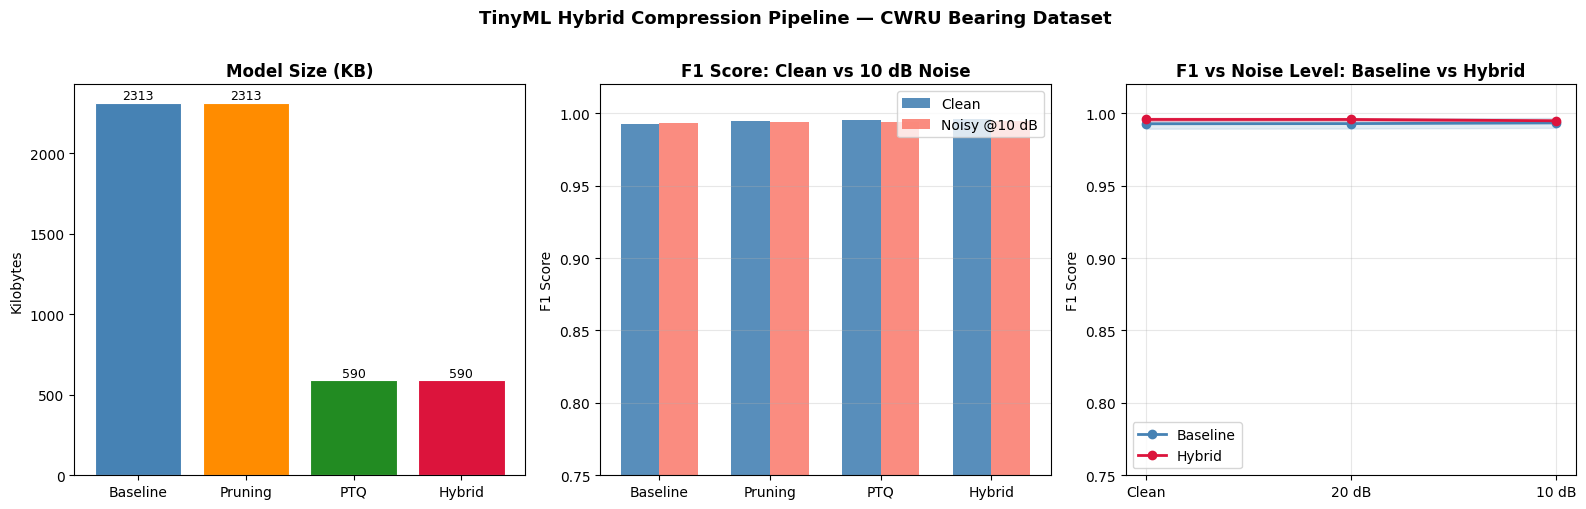

Plot saved → /kaggle/working/results_plot.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
methods  = ['Baseline', 'Pruning', 'PTQ', 'Hybrid']
prefixes = ['bl', 'pr', 'ptq', 'hy']
colors   = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
 
# Plot 1 — Model size comparison
sizes = [df[f'{p}_size'].mean() for p in prefixes]
bars  = axes[0].bar(methods, sizes, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Model Size (KB)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Kilobytes')
for bar, v in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 4,
                 f'{v:.0f}', ha='center', va='bottom', fontsize=9)
 
# Plot 2 — F1 score: clean vs noisy (10 dB)
x     = np.arange(len(methods))
width = 0.35
f1_clean = [df[f'{p}_f1_clean'].mean() for p in prefixes]
f1_noisy = [df[f'{p}_f1_10db'].mean()  for p in prefixes]
axes[1].bar(x - width/2, f1_clean, width, label='Clean',       color='steelblue', alpha=0.9)
axes[1].bar(x + width/2, f1_noisy, width, label='Noisy @10 dB', color='salmon',    alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylim([0.75, 1.02])
axes[1].set_title('F1 Score: Clean vs 10 dB Noise', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
 
# Plot 3 — F1 vs noise level: Baseline vs Hybrid
snr_labels = ['Clean', '20 dB', '10 dB']
for pfx, lbl, col in [('bl', 'Baseline', 'steelblue'), ('hy', 'Hybrid', 'crimson')]:
    f1s = [
        df[f'{pfx}_f1_clean'].mean(),
        df[f'{pfx}_f1_20db'].mean(),
        df[f'{pfx}_f1_10db'].mean(),
    ]
    stds = [
        df[f'{pfx}_f1_clean'].std(),
        df[f'{pfx}_f1_20db'].std(),
        df[f'{pfx}_f1_10db'].std(),
    ]
    axes[2].plot(snr_labels, f1s, marker='o', label=lbl, color=col, linewidth=2)
    axes[2].fill_between(snr_labels,
                         [f - s for f, s in zip(f1s, stds)],
                         [f + s for f, s in zip(f1s, stds)],
                         alpha=0.15, color=col)
axes[2].set_title('F1 vs Noise Level: Baseline vs Hybrid', fontweight='bold', fontsize=12)
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0.75, 1.02])
axes[2].legend()
axes[2].grid(alpha=0.3)
 
plt.suptitle('TinyML Hybrid Compression Pipeline — CWRU Bearing Dataset',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/results_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → /kaggle/working/results_plot.png')
 

In [33]:
# Save the last seed's hybrid INT8 TFLite model
tflite_path = '/kaggle/working/hybrid_model_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(hybrid_bytes)
print(f'Saved hybrid INT8 TFLite model: {len(hybrid_bytes)/1024:.1f} KB')
 
# Save per-seed raw results
raw_df = pd.DataFrame(results)
raw_df.to_csv('/kaggle/working/results_per_seed.csv', index=False)
 
# Final output listing
print('\nOutput files:')
for fn in sorted(os.listdir('/kaggle/working')):
    path = os.path.join('/kaggle/working', fn)
    if os.path.isfile(path):
        print(f'  {fn:<40} {os.path.getsize(path)/1024:.1f} KB')
 

Saved hybrid INT8 TFLite model: 590.2 KB

Output files:
  hybrid_model_int8.tflite                 590.2 KB
  results_per_seed.csv                     1.5 KB
  results_plot.png                         83.2 KB
  results_summary.csv                      0.3 KB


Baseline (Float32)
  TP=7420  TN=460  FP=13  FN=70
  Precision=0.9983  Recall=0.9907  F1=0.9944

Pruning (60%)
  TP=7461  TN=420  FP=53  FN=29
  Precision=0.9929  Recall=0.9961  F1=0.9945

PTQ (INT8)
  TP=7484  TN=409  FP=64  FN=6
  Precision=0.9915  Recall=0.9992  F1=0.9953

Hybrid (Proposed)
  TP=7419  TN=466  FP=7  FN=71
  Precision=0.9991  Recall=0.9905  F1=0.9948



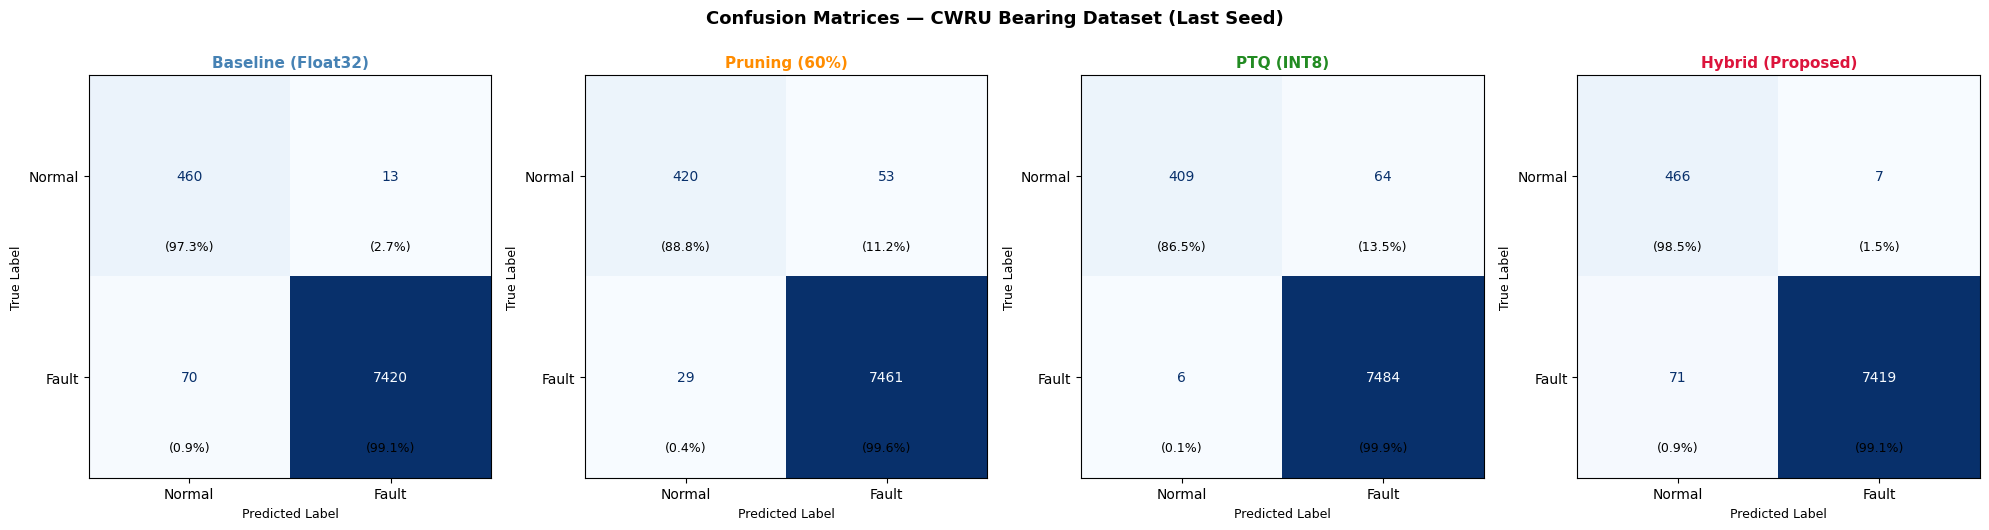

Saved → /kaggle/working/confusion_matrices.png


In [35]:
# ── CELL 7 ── Confusion Matrices for all 4 methods (last seed)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods = [
    ('Baseline (Float32)', 'bl',  'steelblue'),
    ('Pruning (60%)',      'pr',  'darkorange'),
    ('PTQ (INT8)',         'ptq', 'forestgreen'),
    ('Hybrid (Proposed)',  'hy',  'crimson'),
]

np.random.seed(SEEDS[-1])
_, _, X_test_cm, _, _, y_test_cm = make_splits(X_all, y_all, SEEDS[-1])

def get_cm_keras(model, X, y, threshold=0.5):
    preds = (model.predict(X, verbose=0).flatten() >= threshold).astype(int)
    return confusion_matrix(y.astype(int), preds)

def get_cm_tflite(tflite_bytes, X, y, threshold=0.5):
    preds = tflite_predict(tflite_bytes, X)
    return confusion_matrix(y.astype(int), (preds >= threshold).astype(int))

for ax, (title, pfx, color) in zip(axes, methods):
    if pfx == 'bl':
        cm = get_cm_keras(baseline, X_test_cm, y_test_cm)
    elif pfx == 'pr':
        cm = get_cm_keras(pruned, X_test_cm, y_test_cm)
    elif pfx == 'ptq':
        cm = get_cm_tflite(ptq_bytes, X_test_cm, y_test_cm)
    else:
        cm = get_cm_tflite(hybrid_bytes, X_test_cm, y_test_cm)

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # ── FIXED: removed colormap, use cmap only ──
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Fault']
    )
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)

    for i in range(2):
        for j in range(2):
            ax.text(j, i + 0.35, f'({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=9, color='black')

    ax.set_title(title, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f'{title}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
    print(f'  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}\n')

plt.suptitle('Confusion Matrices — CWRU Bearing Dataset (Last Seed)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/confusion_matrices.png')